# LLM editing effect

This notebook uses the existing LLM edits in ../../data.

It uses `text-embedding-3-large` to retrieve new embeddings.

And it reproduces the main plots.

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path("../../.env"))

_required = ["AZURE_OPENAI_ENDPOINT", "AZURE_OPENAI_API_KEY", "AZURE_EMBEDDING_DEPLOYMENT"]
_missing = [k for k in _required if not os.environ.get(k)]
if _missing:
    print("WARNING: missing required .env keys:", _missing)
else:
    print("Embedding deployment:", os.environ["AZURE_EMBEDDING_DEPLOYMENT"])


Embedding deployment: text-embedding-3-large


## Configuration

In [2]:
import os, re, time
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from openai import OpenAI

# Use standard OpenAI API against my Foundry endpoint.
client = OpenAI(
    base_url=os.environ["AZURE_OPENAI_ENDPOINT"].rstrip("/") + "/",
    api_key=os.environ["AZURE_OPENAI_API_KEY"],
)
AZURE_EMBEDDING_DEPLOYMENT = os.environ["AZURE_EMBEDDING_DEPLOYMENT"]

DATA_ROOT = Path("../../data").resolve()
ARGREWRITE_ROOT = DATA_ROOT / "ArgRewrite"
D1_PATH = ARGREWRITE_ROOT / "dataset" / "essays" / "Draft1"
D2_PATH = ARGREWRITE_ROOT / "dataset" / "essays" / "Draft2"
LLM_DRAFTS_ROOT = DATA_ROOT / "llm_drafts"

EMBEDDING_MODELS = {
    "MiniLM-L6": "all-MiniLM-L6-v2",
    "Azure": f"azure:{AZURE_EMBEDDING_DEPLOYMENT}",
}

# Consistent display names.
LLM_DISPLAY_NAMES = {
    "CLAUDE-HAIKU-4-5-20251001": "claude-3.5-haiku",
    "GEMINI-2.5-FLASH": "gemini-2.5-flash",
    "GPT-5-MINI": "gpt-5-mini"
}

# Consistent model coloring (matching your emotion script).
MODEL_COLORS = {
    "HUMAN": "#404040",
    "CLAUDE-HAIKU-4-5-20251001": "#d73027", 
    "GEMINI-2.5-FLASH": "#4575b4",          
    "GPT-5-MINI": "#1b9e77"                 
}

DESCRIPTIVE_NAMES = {
    "minimal": "Minimal Edit",
    "grammar": "Grammar Edits",
    "completion": "Completion",
    "expansion": "Expansion",
    "general": "General Revision",
}

PLOT_ORDER = ["general", "minimal", "grammar", "completion", "expansion"]

Some supporting functions

In [3]:
def super_clean_id(filename):
    """
    Return id from filename, if present.
    """
    nums = re.findall(r"(\d+)", str(filename))
    return str(int(nums[-1])) if nums else str(filename).split('.')[0].strip().lower()

def load_dir_robust(folder):
    texts = {}
    if not folder.is_dir(): return texts
    for fn in os.listdir(folder):
        if fn.lower().endswith(".txt"):
            eid = super_clean_id(fn)
            with open(folder / fn, "r", encoding="utf-8", errors="ignore") as f:
                texts[eid] = f.read().strip()
    return texts

def get_embeddings_batched(text_list, model_id):
    if model_id.startswith("azure:"):
        all_embeddings = []
        
        BATCH_SIZE = 100  # Important, apparently.
        
        for i in range(0, len(text_list), BATCH_SIZE):
            batch = text_list[i : i + BATCH_SIZE]
            
            try:
                resp = client.embeddings.create(model=model_id.split("azure:", 1)[1], input=batch)
                all_embeddings.extend([d.embedding for d in resp.data])
                
            except Exception as e:
                print(f"Error at index {i}: {e}")
                continue
                
        return np.array(all_embeddings)

    return SentenceTransformer(model_id).encode(text_list, show_progress_bar=False)

## Data aggregation

In [4]:
d1_map, d2_map = load_dir_robust(D1_PATH), load_dir_robust(D2_PATH)
common_ids = sorted(set(d1_map.keys()) & set(d2_map.keys()), key=lambda x: int(x))
df_human = pd.DataFrame([{"essay_id": eid, "draft1": d1_map[eid], "draft2": d2_map[eid]} for eid in common_ids])

MODEL_DIRS = [p for p in LLM_DRAFTS_ROOT.iterdir() if p.is_dir()]
all_data_list = []

for folder in MODEL_DIRS:
    model_tag = folder.name.upper()
    if model_tag not in LLM_DISPLAY_NAMES: continue

    for csv_path in folder.glob("*.csv"):
        v_key = "general" if any(x in csv_path.name.lower() for x in ["expert", "general"]) \
                else next((v for v in PLOT_ORDER if v in csv_path.name.lower()), None)
        if not v_key: continue
        ldf = pd.read_csv(csv_path)
        ldf['essay_id'] = ldf['essay_id'].apply(super_clean_id)
        ai_col = 'output_text' if 'output_text' in ldf.columns else 'final_llm_text'
        merged = pd.merge(df_human, ldf[['essay_id', ai_col]], on='essay_id').rename(columns={ai_col: 'ai_text'})
        merged['llm_model'], merged['mode'] = model_tag, v_key
        merged['feedback'] = "With Feedback" if "with_FB" in csv_path.name else "Without Feedback"
        all_data_list.append(merged)

df_master = pd.concat(all_data_list)

## Plotting function

In [5]:
def plot_llm_comparison_grid(llm_id, feedback_status, df_master, df_h, pca_engine, embed_func):

    # Filter data
    llm_data = df_master[(df_master['llm_model'] == llm_id) & (df_master['feedback'] == feedback_status)]
    available_modes = [m for m in PLOT_ORDER if m in llm_data['mode'].unique()]
    
    # Create a grid.
    fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)
    axes_flat = axes.flatten()
    
    # Consistent arrow params.
    ARROW_PARAMS = dict(arrowstyle="-|>", lw=1.2, alpha=0.5)
    m_color = MODEL_COLORS.get(llm_id, "#333333")
    h_color = MODEL_COLORS["HUMAN"]

    # 1. Plot Human Reference in the first slot.
    ax_h = axes_flat[0]
    
    # Fit & transform human coordinates.
    h_coords = pca_engine.transform(normalize(embed_func(df_h['draft1'].tolist() + df_h['draft2'].tolist())))
    h1, h2 = h_coords[:len(df_h)], h_coords[len(df_h):]
    
    # D1 Points (keep black for contrast).
    ax_h.scatter(h1[:,0], h1[:,1], color='black', s=12, alpha=0.3)
    
    # D2 Points.
    ax_h.scatter(h2[:,0], h2[:,1], color=h_color, s=50, alpha=0.8, edgecolors='white', label='Human D2')
    
    # Arrows.
    for i in range(len(df_h)):
        ax_h.annotate('', xy=(h2[i,0], h2[i,1]), xytext=(h1[i,0], h1[i,1]), 
                      arrowprops=dict(color=h_color, **ARROW_PARAMS))
        
    # Title.
    h_shift = np.mean(np.linalg.norm(h2 - h1, axis=1))
    ax_h.set_title(f"Human Reference\n(D1 $\\rightarrow$ D2) | Avg Shift: {h_shift:.3f}", fontweight='bold', fontsize=16)
    ax_h.set_ylabel("PCA Dimension 2", fontsize=14)
    ax_h.grid(True, linestyle='--', alpha=0.2)

    # 2. Plot LLM Modes in remaining slots.
    for idx, mode in enumerate(available_modes):
        ax = axes_flat[idx + 1] # Offset by 1 because Human is at 0.
        m_df = llm_data[llm_data['mode'] == mode]
        
        m_coords = pca_engine.transform(normalize(embed_func(m_df['draft1'].tolist() + m_df['ai_text'].tolist())))
        m1, mai = m_coords[:len(m_df)], m_coords[len(m_df):]
        
        ax.scatter(m1[:,0], m1[:,1], color='black', s=12, alpha=0.3)
        ax.scatter(mai[:,0], mai[:,1], color=m_color, s=50, alpha=0.8, edgecolors='white')
        for j in range(len(m_df)):
            ax.annotate('', xy=(mai[j,0], mai[j,1]), xytext=(m1[j,0], m1[j,1]), 
                        arrowprops=dict(color=m_color, **ARROW_PARAMS))
        
        shift = np.mean(np.linalg.norm(mai - m1, axis=1))
        ax.set_title(f"{DESCRIPTIVE_NAMES.get(mode, mode)}\nAvg Shift: {shift:.3f}", fontweight='bold', fontsize=16)
        ax.grid(True, linestyle='--', alpha=0.2)

    # Remove any unused subplots (if fewer than 5 modes).
    for k in range(len(available_modes) + 1, 6):
        fig.delaxes(axes_flat[k])

    # Labels for the bottom row.
    for i in range(3):
        axes[1, i].set_xlabel("PCA Dimension 1", fontsize=14)
    axes[1, 0].set_ylabel("PCA Dimension 2", fontsize=14)

    llm_display = LLM_DISPLAY_NAMES.get(llm_id, llm_id)
    plt.suptitle(f"Semantic Shifts by {llm_display} ({feedback_status})", 
                 fontsize=20, y=0.95, fontweight='bold', color=m_color)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## Execution


>>> PROCESSING SEMANTIC GROUPS (Embedding: Azure) <<<
Fitting global PCA on 2745 unique texts...
Explained variance ratio (PC1, PC2): [0.084 0.071]


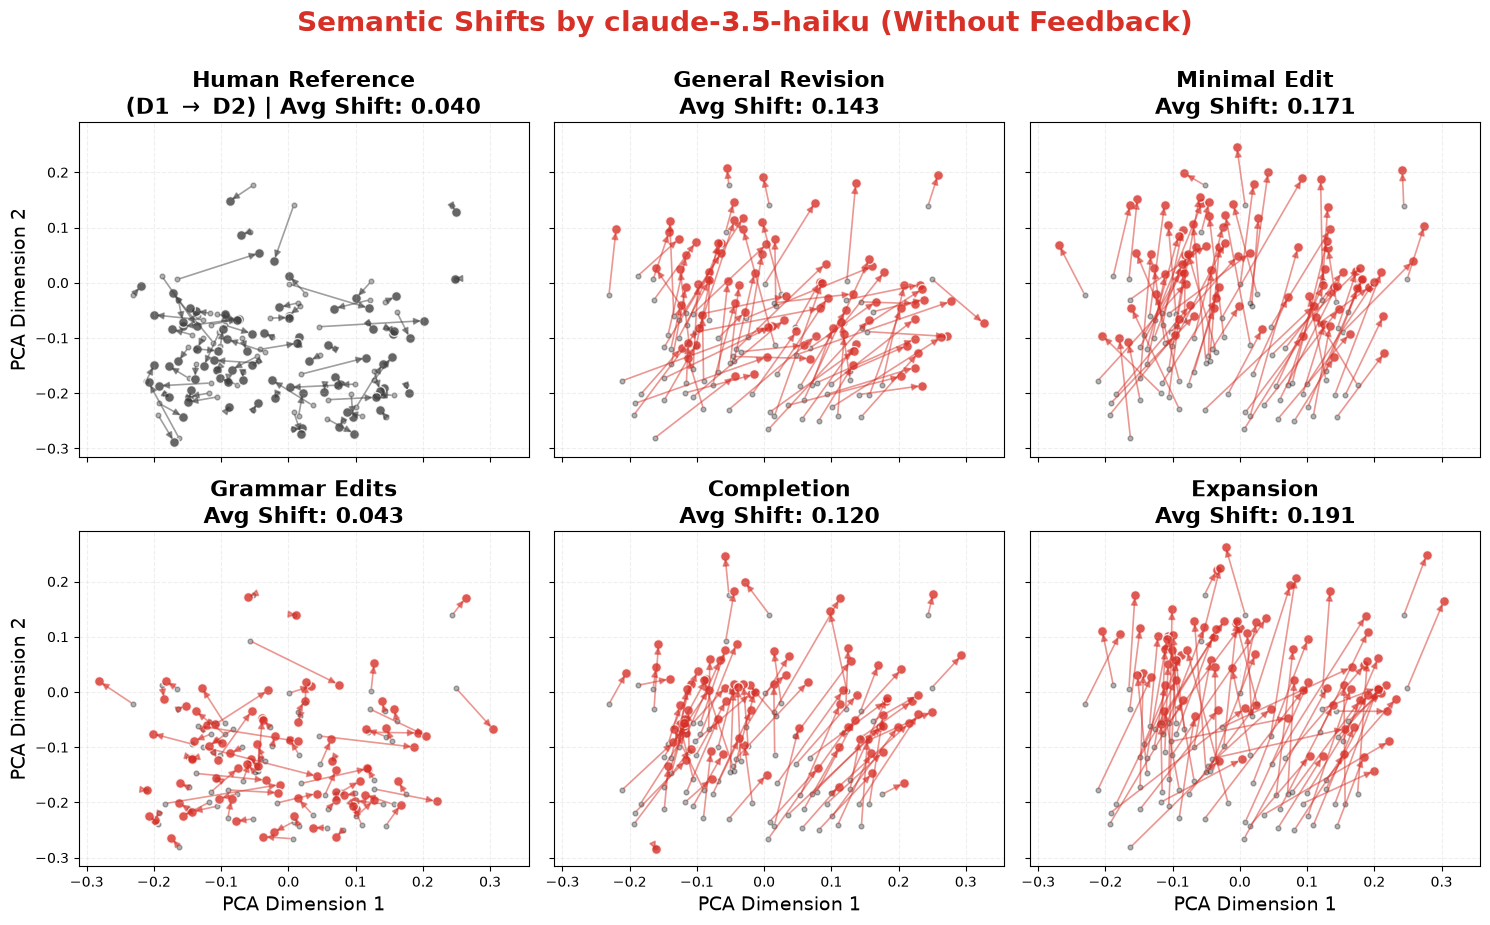

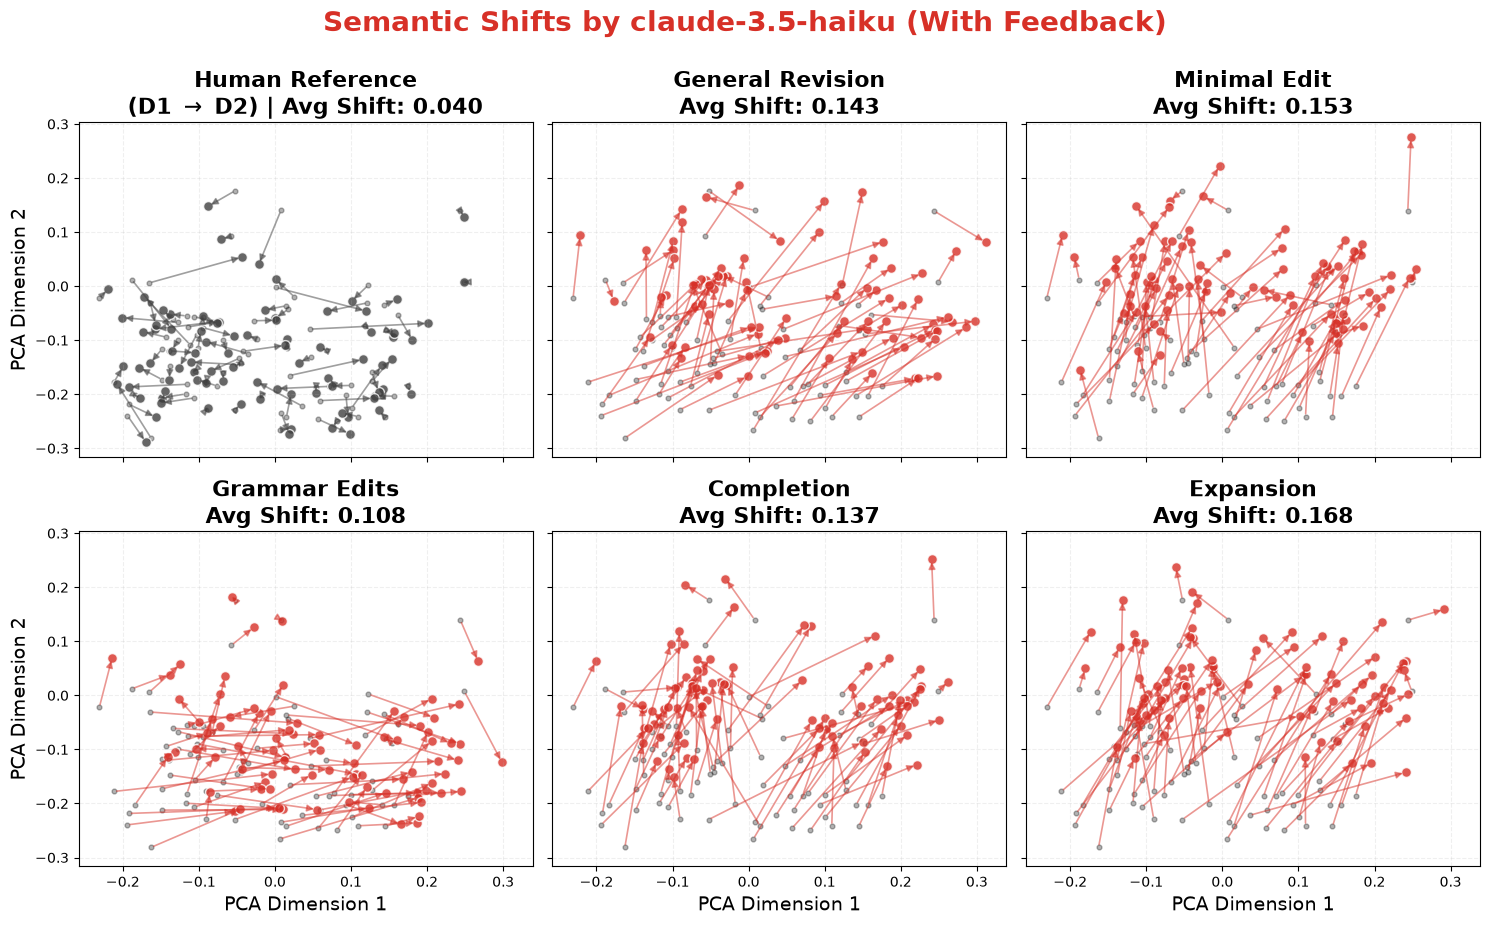

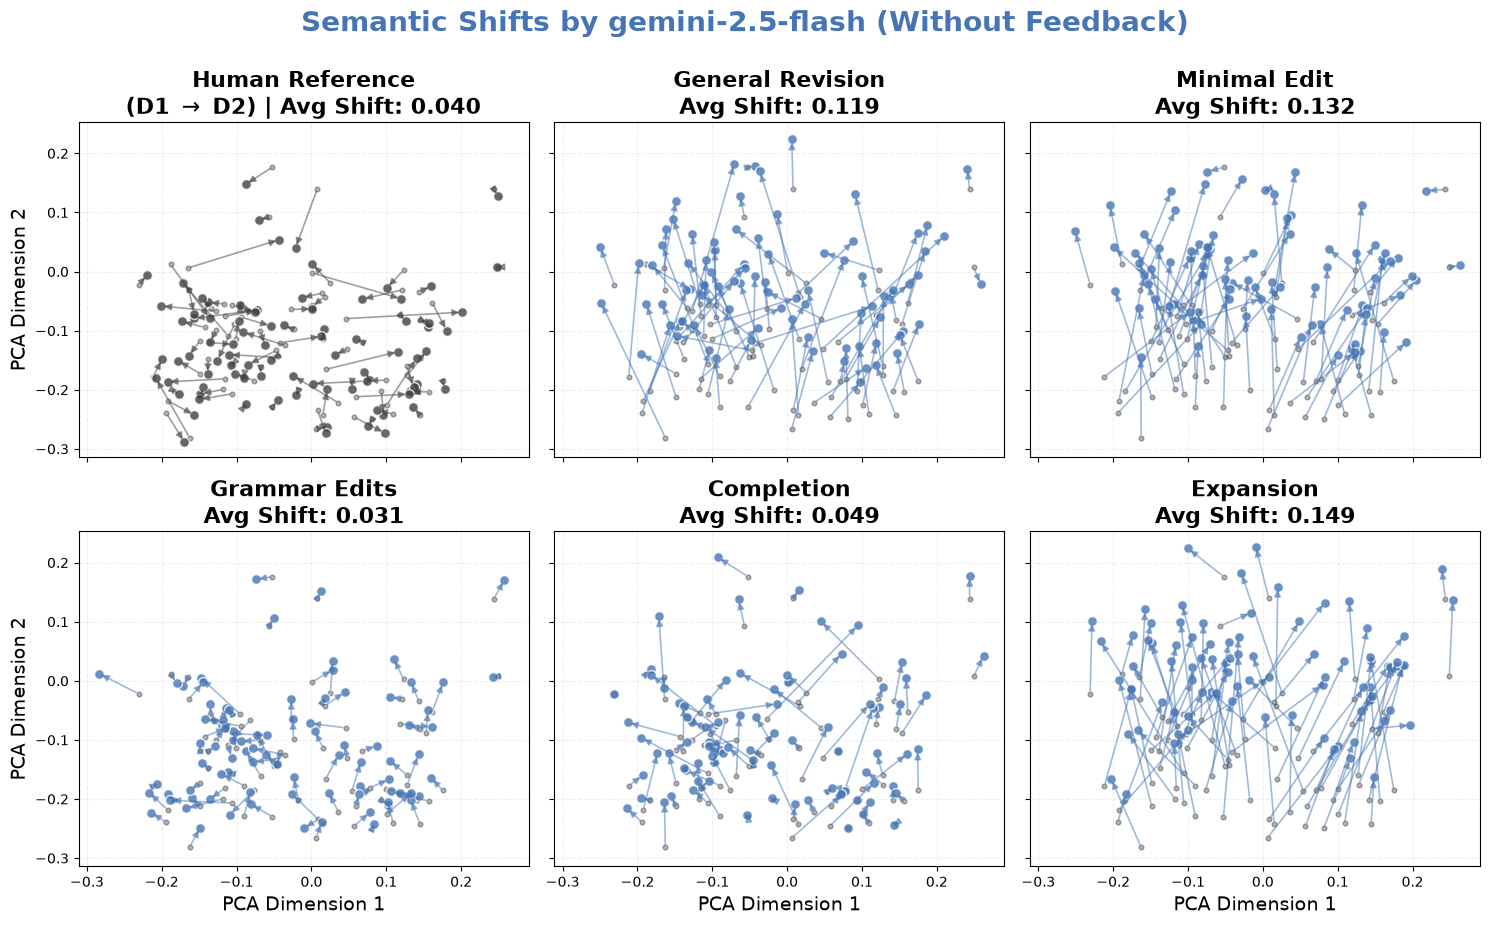

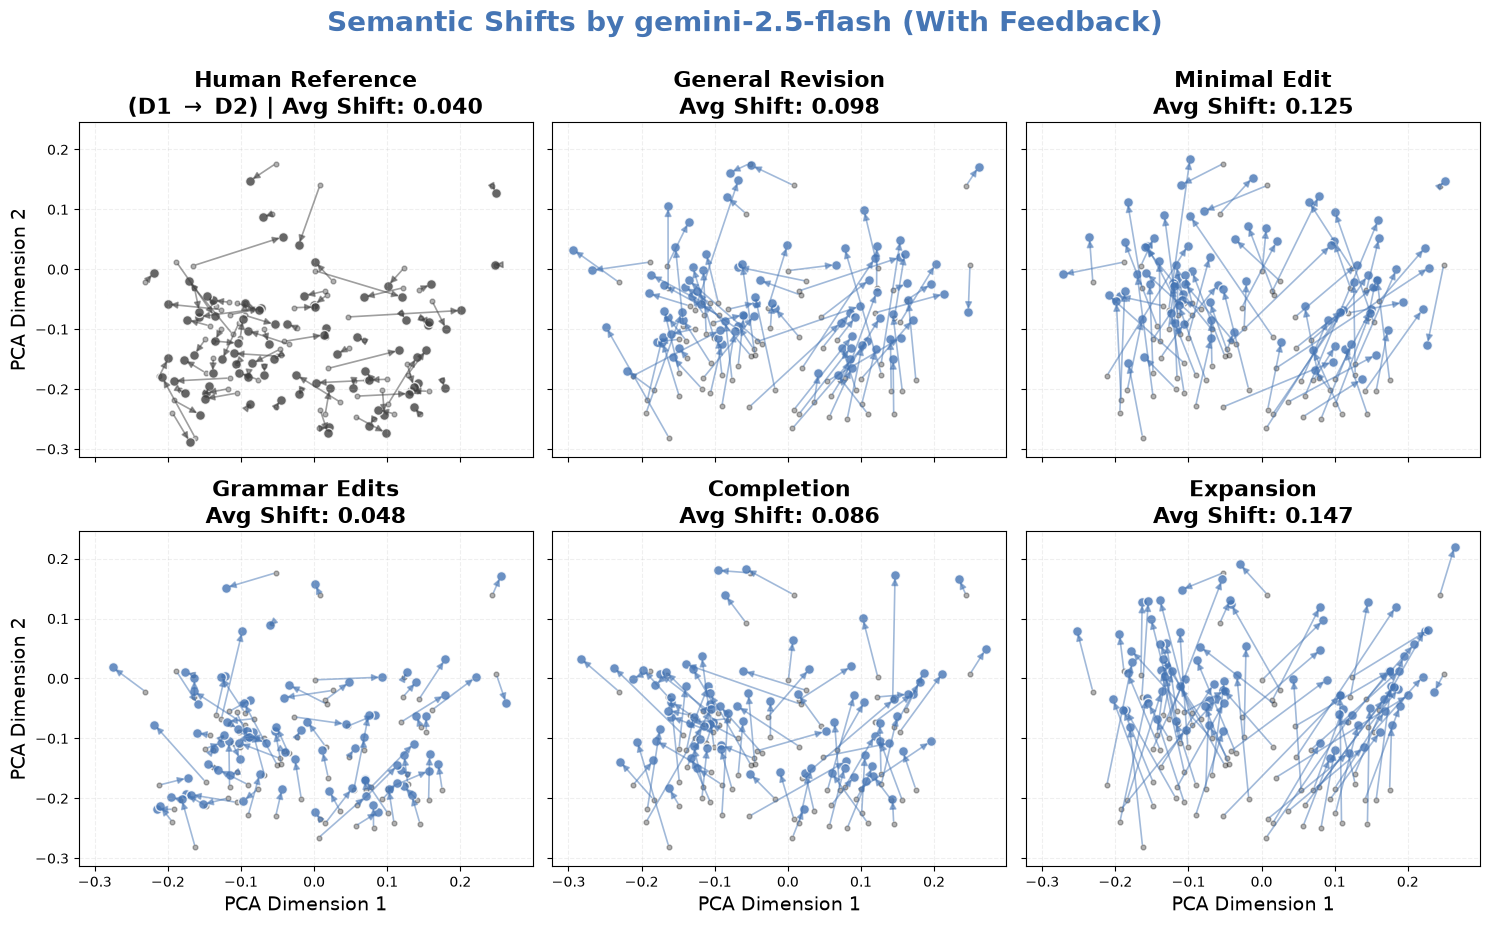

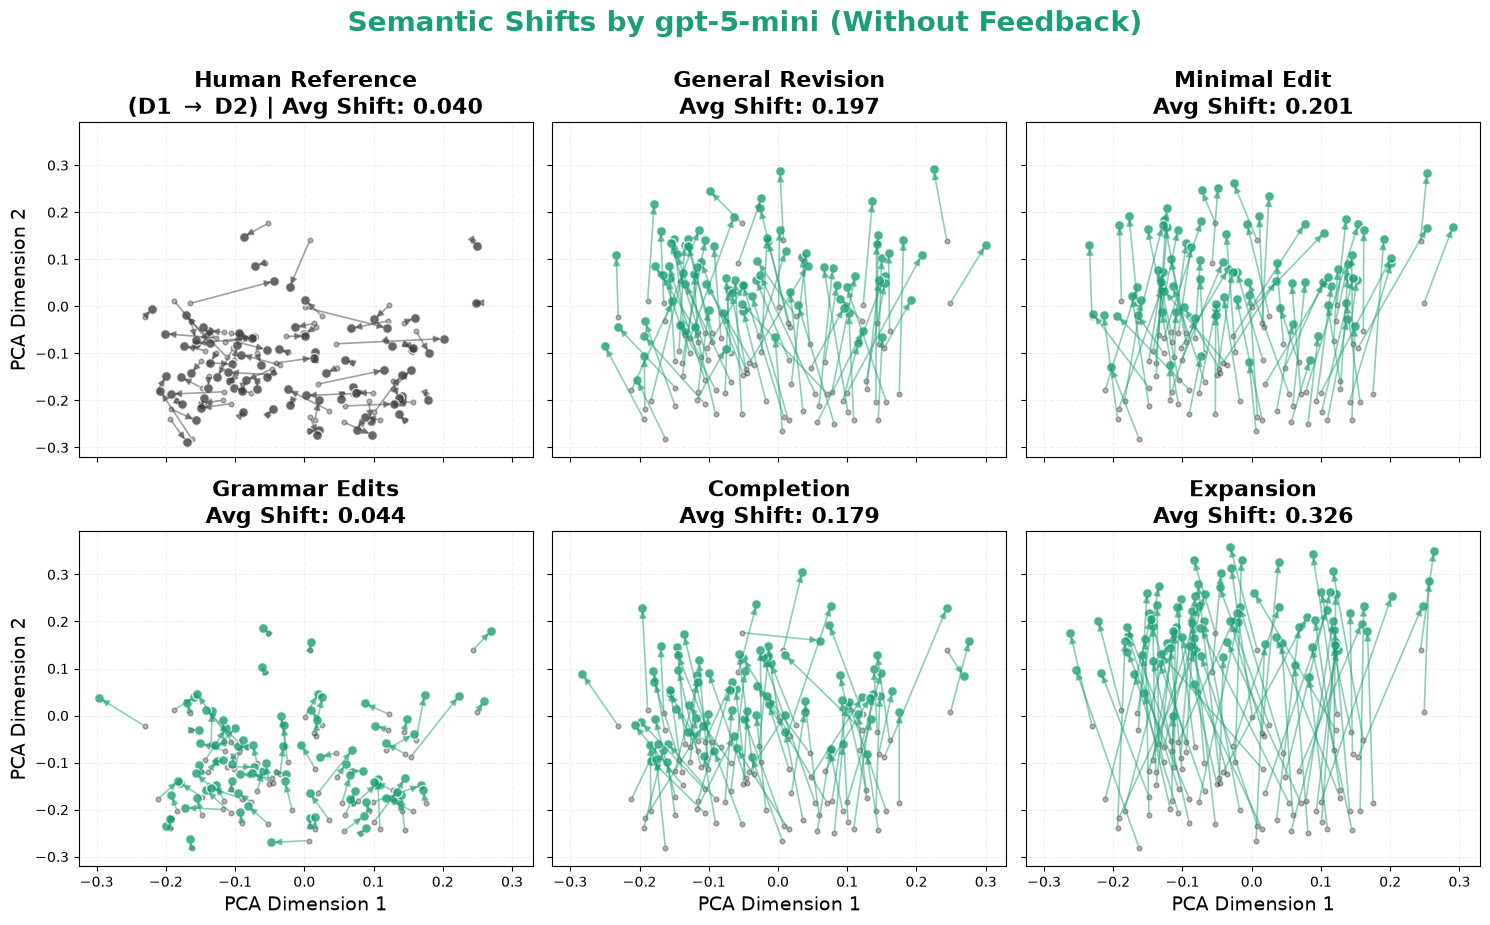

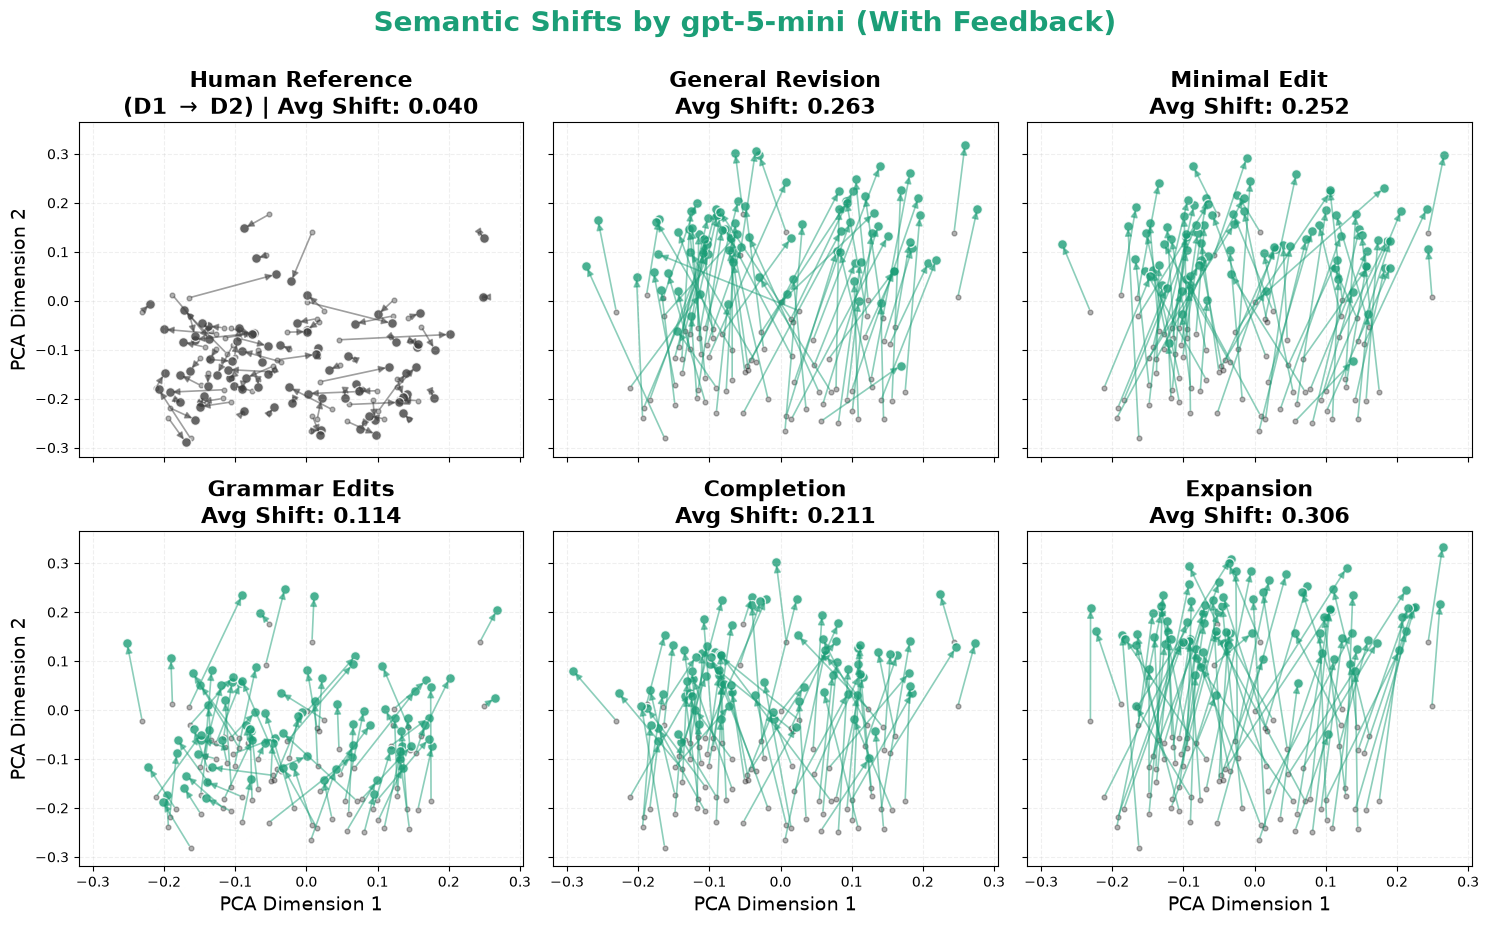

In [6]:
emb_label = "Azure"  # Set to "MiniLM-L6" for the offline local model.
emb_id = EMBEDDING_MODELS[emb_label]
print(f"\n>>> PROCESSING SEMANTIC GROUPS (Embedding: {emb_label}) <<<")

# Memoised embedder: embed each unique text once and reuse it everywhere, so the
# single global PCA fit and every panel's transform share embeddings instead of
# re-calling the embedding API for the same drafts on each panel.
_emb_cache = {}
def cur_embed(texts):
    missing = [t for t in texts if t not in _emb_cache]
    if missing:
        for t, v in zip(missing, get_embeddings_batched(missing, emb_id)):
            _emb_cache[t] = v
    return np.array([_emb_cache[t] for t in texts])

# --- Fit ONE global PCA, shared across every panel ---
# Pool every text that will be plotted (all human drafts + all LLM drafts, both
# feedback conditions and all modes), so PC1/PC2 mean the same thing in every
# figure and shift magnitudes are measured in a single common space.
global_pool = list(set(df_human['draft1'].tolist()
                       + df_human['draft2'].tolist()
                       + df_master['ai_text'].dropna().tolist()))
print(f"Fitting global PCA on {len(global_pool)} unique texts...")
global_pca = PCA(n_components=2).fit(normalize(cur_embed(global_pool)))
print(f"Explained variance ratio (PC1, PC2): {global_pca.explained_variance_ratio_.round(3)}")

for llm_id in LLM_DISPLAY_NAMES.keys():
    for fb in ["Without Feedback", "With Feedback"]:
        # Skip combinations with no data.
        subset = df_master[(df_master['llm_model'] == llm_id) & (df_master['feedback'] == fb)]
        if subset.empty:
            continue
        # Reuse the shared global PCA for every panel (no per-panel refit).
        plot_llm_comparison_grid(llm_id, fb, df_master, df_human, global_pca, cur_embed)
        plt.close('all')


In [5]:
# Persist the aggregated table for the sibling analysis notebooks.
df_master.to_csv("../../data/derived/dataframe_essays_llm_model.csv", index=False)

In [6]:
df_master


,essay_id,draft1,draft2,ai_text,llm_model,mode,feedback
0,1,The topic of self-driving cars is highly debat...,The topic of self-driving cars is both highly ...,# Self-Driving Cars: A Future Worth Pursuing\n...,CLAUDE-HAIKU-4-5-20251001,minimal,Without Feedback
1,2,Self-driving car is a new technology and recei...,Self-driving car is a new technology and recei...,# Self-Driving Cars: A Technology Worth Pursui...,CLAUDE-HAIKU-4-5-20251001,minimal,Without Feedback
2,3,"Self-driving cars, though only recently becomi...","Self-driving cars, though only recently becomi...",# Self-Driving Cars: A Path Forward\n\nSelf-dr...,CLAUDE-HAIKU-4-5-20251001,minimal,Without Feedback
3,4,There are many advantages for the United State...,There are many advantages for the United State...,# Self-Driving Cars: A Life-Saving Imperative\...,CLAUDE-HAIKU-4-5-20251001,minimal,Without Feedback
4,5,When Back to the Future I and II were released...,When Back to the Future I and II were released...,# The Promise and Peril of Self-Driving Cars\n...,CLAUDE-HAIKU-4-5-20251001,minimal,Without Feedback
...,...,...,...,...,...,...,...
81,87,What once seemed like a faraway science fictio...,What once seemed like a faraway science fictio...,What once seemed like a faraway science fictio...,GPT-5-MINI,general,With Feedback
82,100,Car accidents have been a major problem in the...,Car accidents have been a major problem in the...,Car accidents remain a persistent public-healt...,GPT-5-MINI,general,With Feedback
83,101,As technology slowly begins to overtake human ...,As technology slowly begins to overtake human ...,"As technology advances, engineers and investor...",GPT-5-MINI,general,With Feedback
84,102,The idea of having self driving cars may have ...,The idea of having self-driving cars may have ...,The prospect of self-driving cars once seemed ...,GPT-5-MINI,general,With Feedback


### Notes on this notebook

Migrated from the original Google Gemini version to a **Microsoft Azure AI Foundry** embedding deployment. The paper's *semantic shift* reproduction is the pipeline cell above: for each essay it embeds the drafts, L2-normalises, fits a shared 2-component PCA per `(model, feedback)` panel, and reports **Avg Shift** = mean Euclidean distance of the per-essay D1→D2 (human) / D1→AI (LLM) displacement.

**Switch embedding backend** in the execution section: `emb_label = "Azure"` (Azure Foundry) or `emb_label = "MiniLM-L6"` (local `all-MiniLM-L6-v2`, offline — the paper's original).

Several exploratory/duplicate cells from the original notebook (repeated Gemini pipelines, a PCA word-loading biplot, an aggregate-shift plot, a LIWC violin) were removed during migration — some held a hard-coded API key or referenced undefined variables. They remain in git history.
